# 03 Parish-level exploratory data analysis

This notebook compares coworking supply, demand proxies and
public-transport accessibility across all 24 Lisbon parishes.
It exports reusable figures and BI-ready summary tables.

## 1. Imports and data loading

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PARISH_ANALYSIS_BASE_FILE, TABLES_DIR
from src.utils import save_figure

sns.set_theme(style="whitegrid", context="notebook")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(
    PARISH_ANALYSIS_BASE_FILE,
    parse_dates=["collection_date"],
)
print("Analysis table shape:", df.shape)
df.head()

Analysis table shape: (24, 30)


,parish_code,parish,area_km2,population_total,working_age_population_15_64,working_age_population_density_km2,coworking_count,coworking_per_10000_working_age,coworking_density_km2,office_count,...,bus_tram_stop_density_km2,demand_proxy_score,transit_access_score,population_reference_year,collection_date,competition_opportunity_score,median_rent_eur_m2_month,rent_sample_size,rent_coverage_flag,analysis_status
0,110601,Ajuda,2.8739,14306,8591,2989.318,0,0.000,0.000,10,...,29.577,37.92,33.75,2021,2026-07-25,100.00,NaN,0,not_collected,provisional_partial_rent
1,110602,Alcântara,5.0697,13850,8735,1722.982,2,2.290,0.395,31,...,16.175,32.08,12.08,2021,2026-07-25,21.62,NaN,0,not_collected,provisional_partial_rent
2,110654,Alvalade,5.3366,33309,20433,3828.842,4,1.958,0.750,63,...,28.670,60.00,65.83,2021,2026-07-25,37.84,NaN,0,not_collected,provisional_partial_rent
3,110655,Areeiro,1.7173,21160,13319,7755.779,0,0.000,0.000,45,...,30.862,85.42,73.33,2021,2026-07-25,100.00,17.73,10,target_met,provisional_partial_rent
4,110656,Arroios,2.1259,33302,23171,10899.384,7,3.021,3.293,55,...,47.509,94.17,95.00,2021,2026-07-25,10.81,17.50,15,target_met,provisional_partial_rent


## 2. Coverage, missingness and descriptive statistics

Rent is the only intentionally incomplete analysis component.
The pilot covers three priority parishes. All demand,
accessibility and competition fields remain complete.

In [2]:
missing = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(
        missing_percent=lambda table: (
            table["missing_count"] / len(df) * 100
        ).round(2)
    )
)
display(missing[missing["missing_count"] > 0])

metric_columns = [
    "working_age_population_15_64",
    "coworking_count",
    "coworking_per_10000_working_age",
    "demand_proxy_score",
    "transit_access_score",
    "competition_opportunity_score",
]
eda_summary = (
    df[metric_columns]
    .describe()
    .T
    .rename_axis("metric")
    .reset_index()
)
display(eda_summary)

,missing_count,missing_percent
median_rent_eur_m2_month,21,87.5


,metric,count,mean,std,min,25%,50%,75%,max
0,working_age_population_15_64,24.0,14450.333333,6289.982288,6472.00,9093.5000,13436.5000,19928.250,29855.000
1,coworking_count,24.0,2.000000,2.502173,0.00,0.0000,1.0000,3.000,9.000
2,coworking_per_10000_working_age,24.0,1.718375,2.878628,0.00,0.0000,0.9655,2.051,12.203
3,demand_proxy_score,24.0,52.083750,22.942601,14.58,33.0175,48.5450,64.275,94.170
4,transit_access_score,24.0,52.083333,24.983217,10.42,35.0025,50.2050,68.750,96.670
5,competition_opportunity_score,24.0,62.162083,36.825053,0.00,31.0800,62.1600,100.000,100.000


## 3. Coworking supply across all 24 parishes

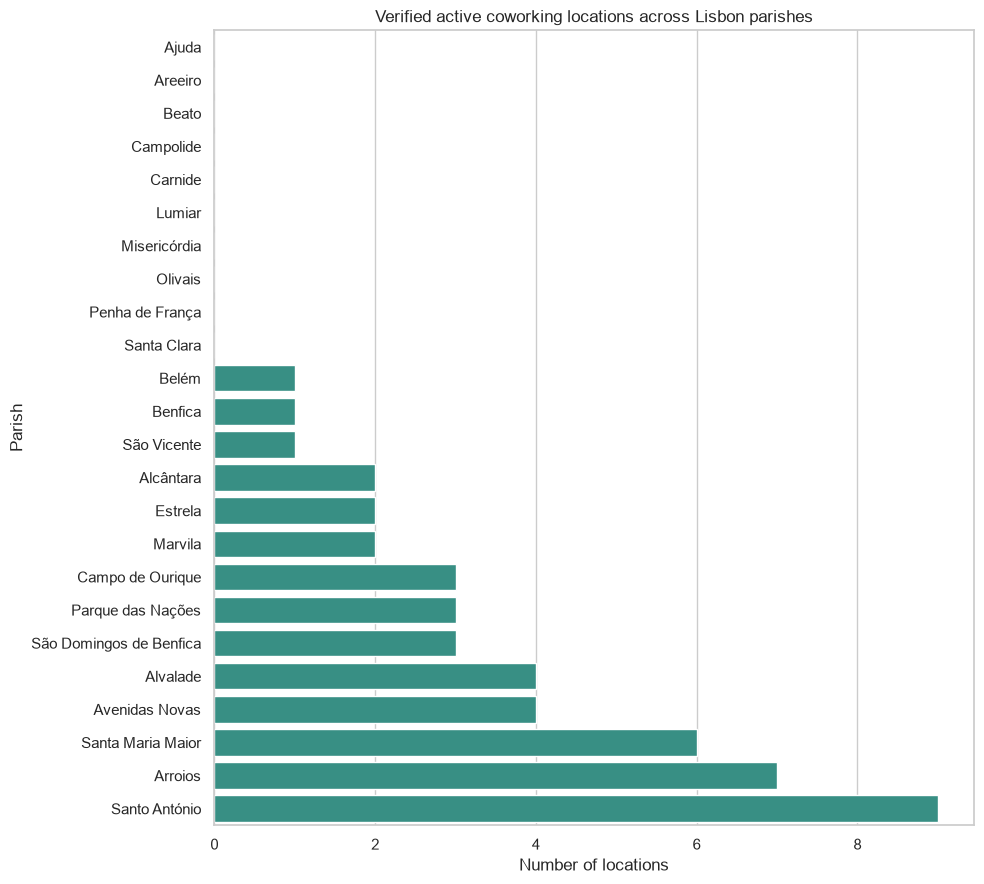

,parish,working_age_population_15_64,demand_proxy_score,transit_access_score,competition_opportunity_score
0,Areeiro,13319,85.42,73.33,100.0
1,Campolide,9490,63.34,55.00,100.0
2,Penha de França,18815,60.42,27.08,100.0
3,Misericórdia,6472,56.67,54.17,100.0
4,Lumiar,29855,43.33,67.50,100.0
5,Carnide,11297,38.75,53.33,100.0
6,Ajuda,8591,37.92,33.75,100.0
7,Beato,7690,33.33,40.00,100.0
8,Santa Clara,15312,30.84,39.17,100.0
9,Olivais,19760,14.58,40.00,100.0


In [3]:
supply = df.sort_values(
    ["coworking_count", "parish"],
    ascending=[True, True],
)
zero_supply = (
    df.loc[
        df["coworking_count"].eq(0),
        [
            "parish",
            "working_age_population_15_64",
            "demand_proxy_score",
            "transit_access_score",
            "competition_opportunity_score",
        ],
    ]
    .sort_values("demand_proxy_score", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(
    data=supply,
    x="coworking_count",
    y="parish",
    color="#2A9D8F",
    ax=ax,
)
ax.set_title("Verified active coworking locations across Lisbon parishes")
ax.set_xlabel("Number of locations")
ax.set_ylabel("Parish")
ax.set_xlim(left=0)
fig.tight_layout()
supply_path = FIGURES_DIR / "02_coworking_supply_all_parishes.png"
save_figure(fig, supply_path)
plt.show()

display(zero_supply)

## 4. Demand versus observed competition

The upper-right area combines stronger demand proxies with
lower observed coworking supply per working-age resident.
Labels highlight the strongest zero-supply candidates rather
than every parish.

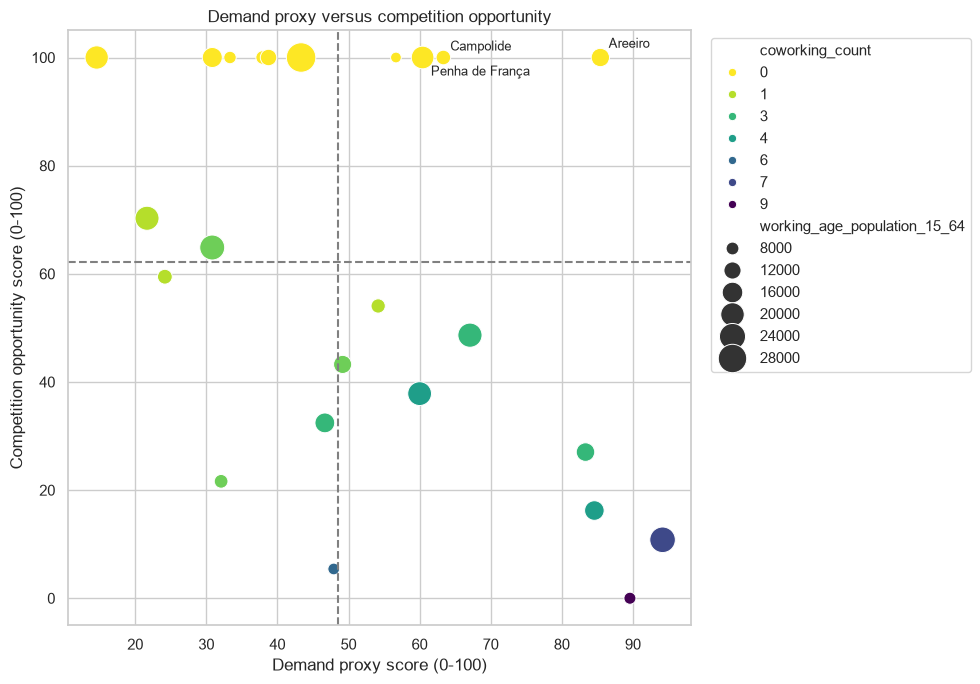

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="demand_proxy_score",
    y="competition_opportunity_score",
    size="working_age_population_15_64",
    hue="coworking_count",
    palette="viridis_r",
    sizes=(60, 450),
    ax=ax,
)
label_rows = (
    df[df["coworking_count"].eq(0)]
    .nlargest(3, "demand_proxy_score")
)
label_offsets = {
    "Areeiro": (6, 7),
    "Penha de França": (6, -13),
    "Misericórdia": (-82, 7),
}
for row in label_rows.itertuples():
    ax.annotate(
        row.parish,
        (row.demand_proxy_score, row.competition_opportunity_score),
        xytext=label_offsets.get(row.parish, (5, 5)),
        textcoords="offset points",
        fontsize=9,
    )
ax.axvline(df["demand_proxy_score"].median(), color="grey", ls="--")
ax.axhline(
    df["competition_opportunity_score"].median(),
    color="grey",
    ls="--",
)
ax.set_title("Demand proxy versus competition opportunity")
ax.set_xlabel("Demand proxy score (0-100)")
ax.set_ylabel("Competition opportunity score (0-100)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
demand_path = FIGURES_DIR / "03_demand_vs_competition.png"
save_figure(fig, demand_path)
plt.show()

## 5. Accessibility versus demand

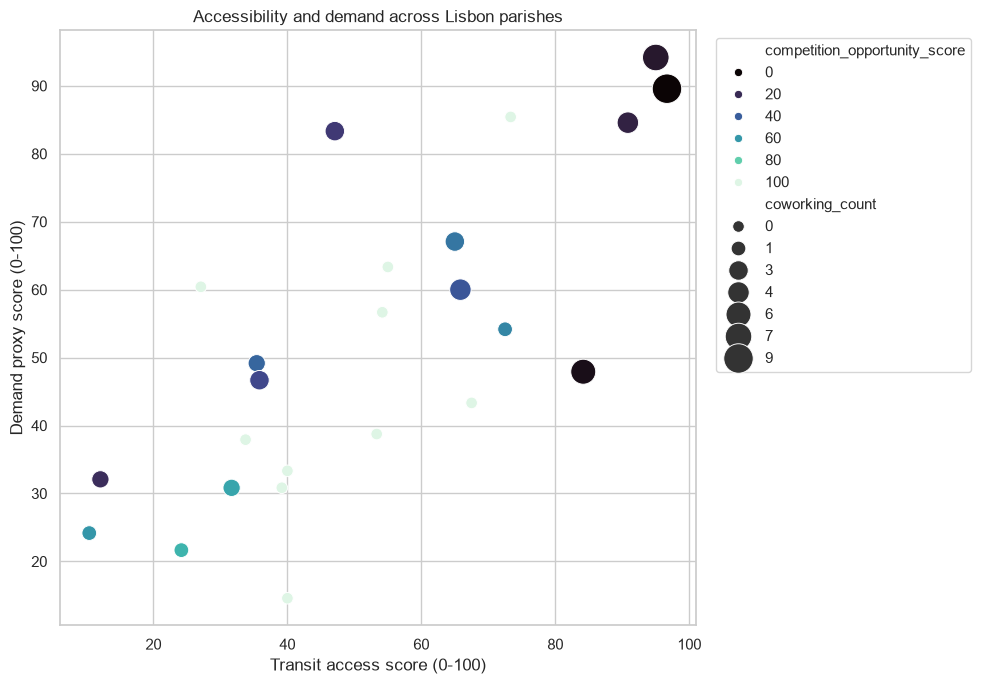

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="transit_access_score",
    y="demand_proxy_score",
    size="coworking_count",
    hue="competition_opportunity_score",
    palette="mako",
    sizes=(70, 450),
    ax=ax,
)
ax.set_title("Accessibility and demand across Lisbon parishes")
ax.set_xlabel("Transit access score (0-100)")
ax.set_ylabel("Demand proxy score (0-100)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
access_path = FIGURES_DIR / "04_accessibility_vs_demand.png"
save_figure(fig, access_path)
plt.show()

## 6. Correlation structure

With only 24 parishes, correlations are descriptive and should
not be interpreted as causal evidence.

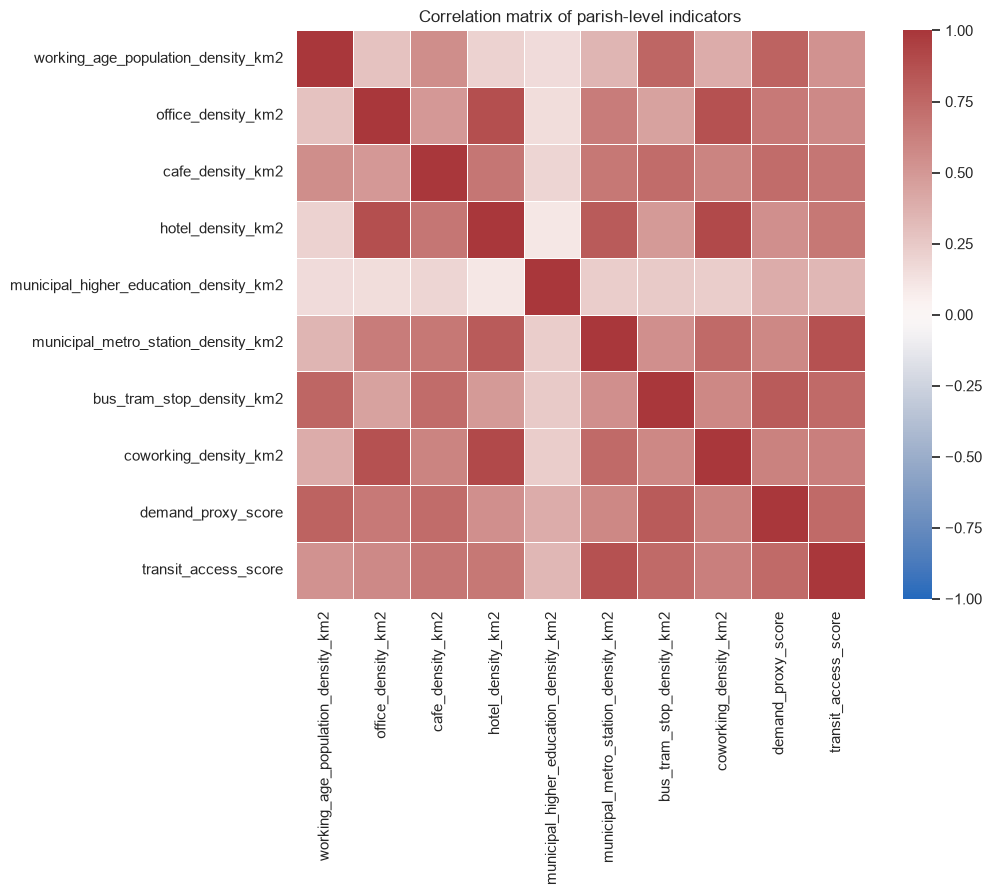

In [6]:
correlation_columns = [
    "working_age_population_density_km2",
    "office_density_km2",
    "cafe_density_km2",
    "hotel_density_km2",
    "municipal_higher_education_density_km2",
    "municipal_metro_station_density_km2",
    "bus_tram_stop_density_km2",
    "coworking_density_km2",
    "demand_proxy_score",
    "transit_access_score",
]
correlation = df[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation matrix of parish-level indicators")
fig.tight_layout()
correlation_path = FIGURES_DIR / "05_indicator_correlation_heatmap.png"
save_figure(fig, correlation_path)
plt.show()

## 7. Pilot commercial asking-rent comparison

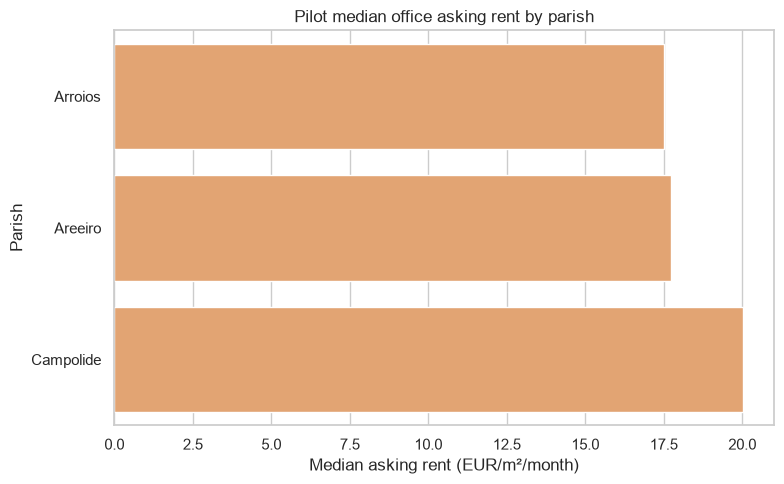

,parish,median_rent_eur_m2_month,rent_sample_size,rent_coverage_flag
0,Arroios,17.50,15,target_met
1,Areeiro,17.73,10,target_met
2,Campolide,20.01,10,target_met


In [7]:
rent_pilot = (
    df.loc[
        df["median_rent_eur_m2_month"].notna(),
        [
            "parish",
            "median_rent_eur_m2_month",
            "rent_sample_size",
            "rent_coverage_flag",
        ],
    ]
    .sort_values("median_rent_eur_m2_month")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=rent_pilot,
    x="median_rent_eur_m2_month",
    y="parish",
    color="#F4A261",
    ax=ax,
)
ax.set_title("Pilot median office asking rent by parish")
ax.set_xlabel("Median asking rent (EUR/m²/month)")
ax.set_ylabel("Parish")
fig.tight_layout()
rent_path = FIGURES_DIR / "08_pilot_commercial_rent.png"
save_figure(fig, rent_path)
plt.show()

display(rent_pilot)

## 8. Export EDA tables and key observations

In [8]:
eda_summary_path = TABLES_DIR / "parish_eda_summary.csv"
zero_supply_path = TABLES_DIR / "zero_coworking_parishes.csv"
rent_pilot_path = TABLES_DIR / "commercial_rent_pilot.csv"
eda_summary.to_csv(eda_summary_path, index=False)
zero_supply.to_csv(zero_supply_path, index=False)
rent_pilot.to_csv(rent_pilot_path, index=False)

highest_supply = df.nlargest(3, "coworking_count")[
    ["parish", "coworking_count"]
]
strongest_zero_supply = zero_supply.head(3)[
    ["parish", "demand_proxy_score", "transit_access_score"]
]

print("Parishes with the most verified coworking locations:")
display(highest_supply)
print("Highest-demand parishes with zero verified locations:")
display(strongest_zero_supply)
print("Zero-coworking parishes:", len(zero_supply))
print("Rent coverage:", int(df["median_rent_eur_m2_month"].notna().sum()), "/ 24")
print("Saved:", eda_summary_path.relative_to(PROJECT_ROOT))
print("Saved:", zero_supply_path.relative_to(PROJECT_ROOT))
print("Saved:", rent_pilot_path.relative_to(PROJECT_ROOT))

Parishes with the most verified coworking locations:


,parish,coworking_count
21,Santo António,9
4,Arroios,7
20,Santa Maria Maior,6


Highest-demand parishes with zero verified locations:


,parish,demand_proxy_score,transit_access_score
0,Areeiro,85.42,73.33
1,Campolide,63.34,55.00
2,Penha de França,60.42,27.08


Zero-coworking parishes: 10
Rent coverage: 3 / 24
Saved: reports/tables/parish_eda_summary.csv
Saved: reports/tables/zero_coworking_parishes.csv
Saved: reports/tables/commercial_rent_pilot.csv


## 8. EDA interpretation

The analysis reveals substantial geographic concentration:
several parishes have no verified active coworking locations,
while a small group contains most observed supply. Demand and
transit signals vary independently enough to justify a
multi-component decision model. Rent is usable for three
priority parishes but not citywide, so the main ranking remains
provisional.